# LoRaSim Simulation Report

This report addresses **Exercise Question 3 (EQ3)** from the paper *"Do LoRa Low-Power Wide-Area Networks Scale?"* by M. Bor et al. 

The aim is to:
- Reproduce **Figure 5** and **Figure 7** using the **LoRaSim** simulator.
- Follow the simulation parameters as closely as possible.
- Present the results in a similar format for direct comparison.

---


In [1]:
! wget https://www.lancaster.ac.uk/scc/sites/lora/lorasim-20170710.tgz
! tar -xvf lorasim-20170710.tgz

!sudo apt-get install python2 && curl https://bootstrap.pypa.io/pip/2.7/get-pip.py -o get-pip.py && python2 get-pip.py && rm get-pip.py
!sudo apt install python-tk
!pip2 install -r 'lorasim/requirements.txt'

--2025-04-26 23:29:21--  https://www.lancaster.ac.uk/scc/sites/lora/lorasim-20170710.tgz
Resolving www.lancaster.ac.uk (www.lancaster.ac.uk)... 148.88.65.80, 2001:630:80:2ff::80:1
Connecting to www.lancaster.ac.uk (www.lancaster.ac.uk)|148.88.65.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 112640 (110K) [application/x-gzip]
Saving to: ‘lorasim-20170710.tgz.1’

lorasim-20170710.tg 100%[===================>] 110.00K   320KB/s    in 0.3s    

2025-04-26 23:29:22 (320 KB/s) - ‘lorasim-20170710.tgz.1’ saved [112640/112640]

lorasim/
lorasim/loraDir.py
lorasim/loraDirMulBS.py
lorasim/oneDirectionalLoraIntf.py
lorasim/requirements.txt
lorasim/directionalLoraIntf.py
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python2 is already the newest version (2.7.18-3).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
          

In [4]:
import os
import pandas as pd
import math
import subprocess
import matplotlib
import matplotlib.pyplot as plt

In [5]:
def simulate(n_nodes, tx_rate, exp, duration):
    env = os.environ.copy()
    env["MPLBACKEND"] = "Agg"

    # Use subprocess.run to execute the command and capture output
    result = subprocess.run(
        [
            "python2",
            "lorasim/loraDir.py",
            str(int(n_nodes)),
            str(int(tx_rate)),
            str(int(exp)),
            str(int(duration)),
            "1"
        ],
        env=env,
        capture_output=True,
        text=True,  # Capture output as text
    )

    # Print the output
    # print(result.stdout)
    # print(result.stderr)

In [6]:
duration = 86400000
tx_rate = 1e6

for n_nodes in list(range(1,90,49)) + list(range(100,1000,100)) + list(range(1000,1700,200)):
  print(f"Simulating {n_nodes} nodes")
  simulate(n_nodes, tx_rate, 4, duration)
  simulate(n_nodes, tx_rate, 3, duration)
  simulate(n_nodes, tx_rate, 5, duration)

Simulating 1 nodes
Simulating 50 nodes
Simulating 100 nodes
Simulating 200 nodes
Simulating 300 nodes
Simulating 400 nodes
Simulating 500 nodes
Simulating 600 nodes
Simulating 700 nodes
Simulating 800 nodes
Simulating 900 nodes
Simulating 1000 nodes
Simulating 1200 nodes
Simulating 1400 nodes
Simulating 1600 nodes


In [7]:
data3 = pd.read_csv("exp4.dat", sep=" ")
data4 = pd.read_csv("exp3.dat", sep=" ")
data5 = pd.read_csv("exp5.dat", sep=" ")

data3["der"] = (data3["nrTransmissions"] - data3["nrCollisions"]) / data3["nrTransmissions"]
data4["der"] = (data4["nrTransmissions"] - data4["nrCollisions"]) / data4["nrTransmissions"]
data5["der"] = (data5["nrTransmissions"] - data5["nrCollisions"]) / data5["nrTransmissions"]

## Reproduction of Figure 5

In this section, we simulate the results corresponding to **Figure 5** from the paper.
The parameters used match those described in the original experimental setup.


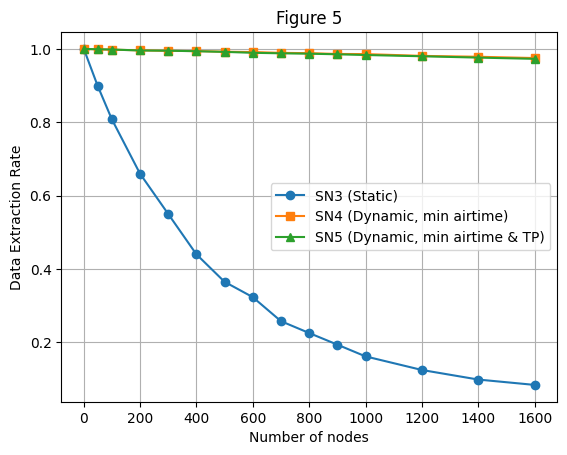

In [8]:
plt.plot(data3["#nrNodes"], data3["der"], label="SN3 (Static)",marker='o', linestyle='-')
plt.plot(data4["#nrNodes"], data4["der"], label="SN4 (Dynamic, min airtime)",marker='s', linestyle='-')
plt.plot(data5["#nrNodes"], data5["der"], label="SN5 (Dynamic, min airtime & TP)",marker='^', linestyle='-')
plt.title("Figure 5")
plt.xlabel("Number of nodes")
plt.ylabel("Data Extraction Rate")
plt.legend()
plt.grid()
plt.show()

In [9]:
def simulate_multibs(n_nodes, tx_rate, exp, duration, sinks):
    env = os.environ.copy()
    env["MPLBACKEND"] = "Agg"

    result = subprocess.run(
        [
            "python2",
            "lorasim/loraDirMulBS.py",
            str(int(n_nodes)),
            str(int(tx_rate)),
            str(int(exp)),
            str(int(duration)),
            str(int(sinks)),
            "1"
        ],
        env=env,
        capture_output=True,
        text=True,
    )

    # Print the output
    # print(result.stdout)
    # print(result.stderr)

In [10]:
duration = 86400000  # 1 day in milliseconds
tx_rate = 1e6        # packet interval
sinks_list = [1, 2, 3, 4, 8, 24]
nodes_range = list(range(1,90,49)) + list(range(100,1000,100)) + list(range(1000,1700,200))

# Run simulations
for sinks in sinks_list:
    for n_nodes in nodes_range:
        print(f"Simulating {n_nodes} nodes for {sinks} sinks")
        simulate_multibs(n_nodes, tx_rate, 0, duration, sinks)

Simulating 1 nodes for 1 sinks
Simulating 50 nodes for 1 sinks
Simulating 100 nodes for 1 sinks
Simulating 200 nodes for 1 sinks
Simulating 300 nodes for 1 sinks
Simulating 400 nodes for 1 sinks
Simulating 500 nodes for 1 sinks
Simulating 600 nodes for 1 sinks
Simulating 700 nodes for 1 sinks
Simulating 800 nodes for 1 sinks
Simulating 900 nodes for 1 sinks
Simulating 1000 nodes for 1 sinks
Simulating 1200 nodes for 1 sinks
Simulating 1400 nodes for 1 sinks
Simulating 1600 nodes for 1 sinks
Simulating 1 nodes for 2 sinks
Simulating 50 nodes for 2 sinks
Simulating 100 nodes for 2 sinks
Simulating 200 nodes for 2 sinks
Simulating 300 nodes for 2 sinks
Simulating 400 nodes for 2 sinks
Simulating 500 nodes for 2 sinks
Simulating 600 nodes for 2 sinks
Simulating 700 nodes for 2 sinks
Simulating 800 nodes for 2 sinks
Simulating 900 nodes for 2 sinks
Simulating 1000 nodes for 2 sinks
Simulating 1200 nodes for 2 sinks
Simulating 1400 nodes for 2 sinks
Simulating 1600 nodes for 2 sinks
Simulati

In [11]:
# Read all data
data = {}
for sinks in sinks_list:
    filename = f"exp0BS{sinks}.dat"
    d = pd.read_csv(filename, sep=" ", comment="#", header=None, names=["nodes", "DER"])
    data[sinks] = d

## Reproduction of Figure 7

Here we simulate and plot the results corresponding to **Figure 7** from the paper,
maintaining alignment with the original parameters and conditions.


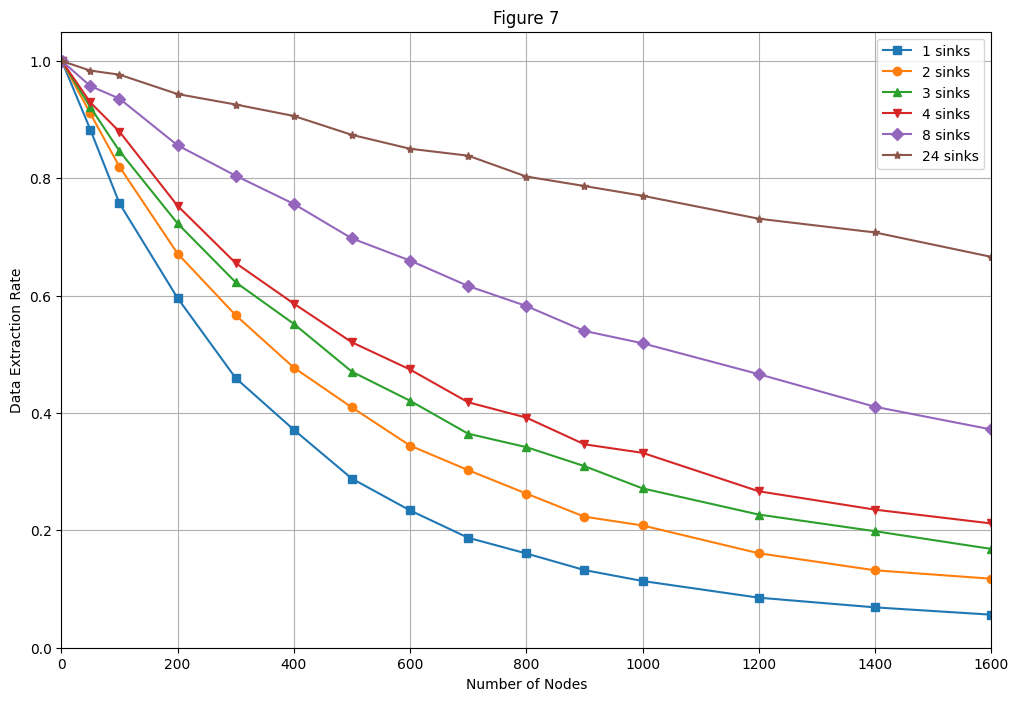

In [12]:
# Plotting
plt.figure(figsize=(12,8))
markers = {1: 's', 2: 'o', 3: '^', 4: 'v', 8: 'D', 24: '*'}
for sinks in sinks_list:
    plt.plot(data[sinks]["nodes"], data[sinks]["DER"], label=f"{sinks} sinks", marker=markers[sinks], linestyle='-')

plt.xlabel("Number of Nodes")
plt.ylabel("Data Extraction Rate")
plt.title("Figure 7")
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)
plt.xlim(0, 1600)
plt.show()